In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder

In [30]:
df = pd.read_csv("global-data-on-sustainable-energy.csv")
df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


In [31]:
df.shape

(3649, 21)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7   Electricity from fossil fuels (TW

In [33]:
df.describe()

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Latitude,Longitude
count,3649.000000,3639.000000,3480.000000,2718.000000,1.560000e+03,3455.000000,3628.000000,3523.000000,3628.000000,3607.000000,3649.000000,3442.000000,3.221000e+03,1512.000000,3332.000000,3367.000000,3.648000e+03,3648.000000,3648.000000
mean,2010.038367,78.933702,63.255287,113.137498,9.422400e+07,32.638165,70.365003,13.450190,23.968010,36.801182,25743.981745,5.307345,1.598665e+05,11.986707,3.441610,13283.774348,6.332135e+05,18.246388,14.822695
std,6.054228,30.275541,39.043658,244.167256,2.981544e+08,29.894901,348.051866,73.006623,104.431085,34.314884,34773.221366,3.532020,7.736611e+05,14.994644,5.686720,19709.866716,1.585519e+06,24.159232,66.348148
min,2000.000000,1.252269,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.110000,1.000000e+01,0.000000,-62.075920,111.927225,2.100000e+01,-40.900557,-175.198242
25%,2005.000000,59.800890,23.175000,3.540000,2.600000e+05,6.515000,0.290000,0.000000,0.040000,2.877847,3116.737300,3.170000,2.020000e+03,2.137095,1.383302,1337.813437,2.571300e+04,3.202778,-11.779889
50%,2010.000000,98.361570,83.150000,32.910000,5.665000e+06,23.300000,2.970000,0.000000,1.470000,27.865068,13120.570000,4.300000,1.050000e+04,6.290766,3.559855,4578.633208,1.176000e+05,17.189877,19.145136
75%,2015.000000,100.000000,100.000000,112.210000,5.534750e+07,55.245000,26.837500,0.000000,9.600000,64.403792,33892.780000,6.027500,6.058000e+04,16.841638,5.830099,15768.615365,5.131200e+05,38.969719,46.199616
max,2020.000000,100.000000,100.000000,3060.190000,5.202310e+09,96.040000,5184.130000,809.410000,2184.940000,100.000010,262585.700000,32.570000,1.070722e+07,86.836586,123.139555,123514.196700,9.984670e+06,64.963051,178.065032


In [34]:
print(df.columns)


Index(['Entity', 'Year', 'Access to electricity (% of population)',
       'Access to clean fuels for cooking',
       'Renewable-electricity-generating-capacity-per-capita',
       'Financial flows to developing countries (US $)',
       'Renewable energy share in the total final energy consumption (%)',
       'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)',
       'Electricity from renewables (TWh)',
       'Low-carbon electricity (% electricity)',
       'Primary energy consumption per capita (kWh/person)',
       'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
       'Value_co2_emissions_kt_by_country',
       'Renewables (% equivalent primary energy)', 'gdp_growth',
       'gdp_per_capita', 'Density\n(P/Km2)', 'Land Area(Km2)', 'Latitude',
       'Longitude'],
      dtype='object')


In [35]:
df.isnull().sum()

Entity                                                                 0
Year                                                                   0
Access to electricity (% of population)                               10
Access to clean fuels for cooking                                    169
Renewable-electricity-generating-capacity-per-capita                 931
Financial flows to developing countries (US $)                      2089
Renewable energy share in the total final energy consumption (%)     194
Electricity from fossil fuels (TWh)                                   21
Electricity from nuclear (TWh)                                       126
Electricity from renewables (TWh)                                     21
Low-carbon electricity (% electricity)                                42
Primary energy consumption per capita (kWh/person)                     0
Energy intensity level of primary energy (MJ/$2017 PPP GDP)          207
Value_co2_emissions_kt_by_country                  

In [37]:
# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median())

In [38]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0])

In [39]:
df.isnull().sum()

Entity                                                              0
Year                                                                0
Access to electricity (% of population)                             0
Access to clean fuels for cooking                                   0
Renewable-electricity-generating-capacity-per-capita                0
Financial flows to developing countries (US $)                      0
Renewable energy share in the total final energy consumption (%)    0
Electricity from fossil fuels (TWh)                                 0
Electricity from nuclear (TWh)                                      0
Electricity from renewables (TWh)                                   0
Low-carbon electricity (% electricity)                              0
Primary energy consumption per capita (kWh/person)                  0
Energy intensity level of primary energy (MJ/$2017 PPP GDP)         0
Value_co2_emissions_kt_by_country                                   0
Renewables (% equiva

In [40]:
df["Total Electricity Production"] = (
    df["Electricity from fossil fuels (TWh)"] +
    df["Electricity from renewables (TWh)"] +
    df["Electricity from nuclear (TWh)"]
)

In [41]:
df["Renewable Ratio"] = (
    df["Electricity from renewables (TWh)"] /
    df["Total Electricity Production"]
)

In [43]:
df["Renewable Ratio"].replace([np.inf, -np.inf], 0)
df["Renewable Ratio"].fillna(0)

0       0.659574
1       0.847458
2       0.811594
3       0.670213
4       0.629213
          ...   
3644    0.486804
3645    0.585034
3646    0.594124
3647    0.555825
3648    0.552042
Name: Renewable Ratio, Length: 3649, dtype: float64

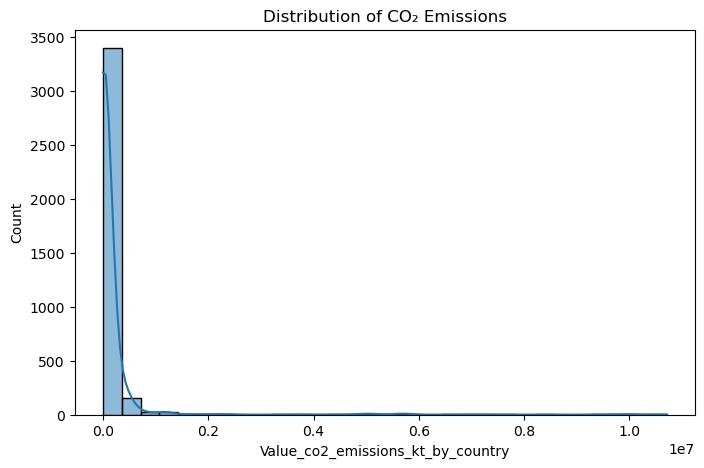

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(df["Value_co2_emissions_kt_by_country"], bins=30, kde=True)
plt.title("Distribution of CO₂ Emissions")
plt.show()

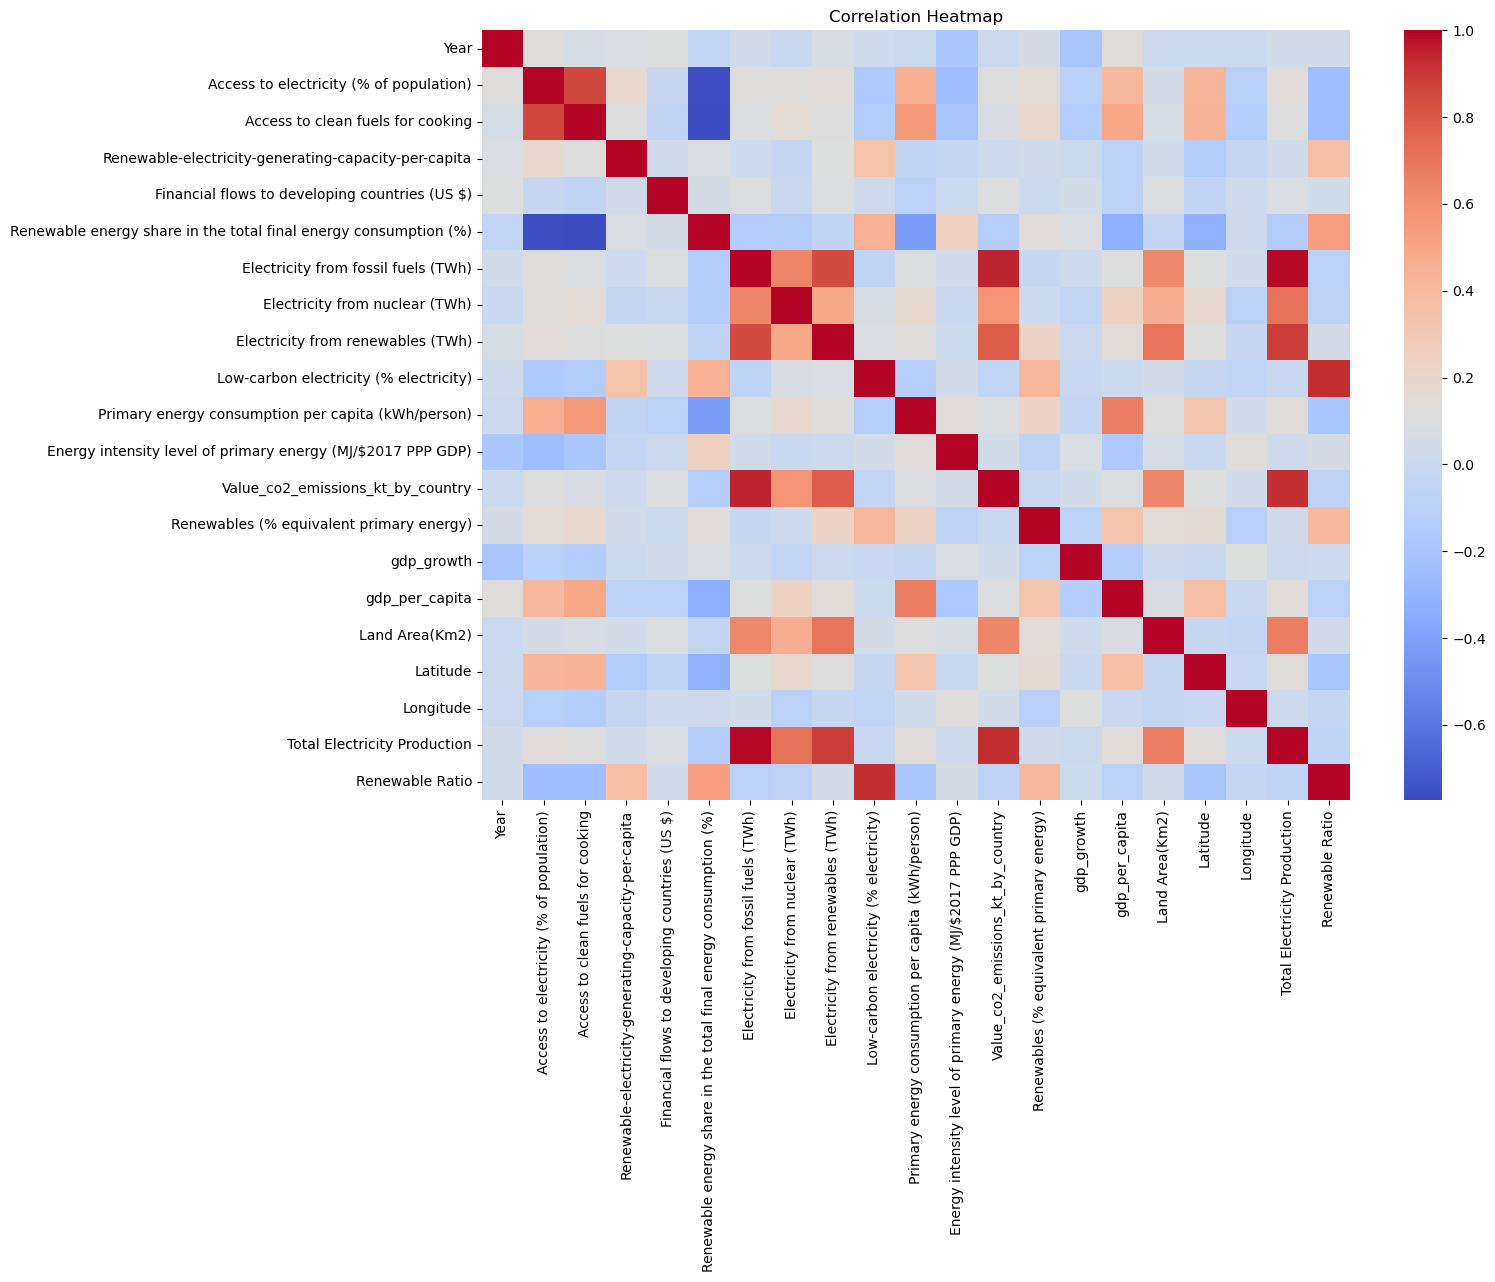

In [45]:
plt.figure(figsize=(14,10))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            cmap="coolwarm",
            annot=False)

plt.title("Correlation Heatmap")
plt.show()

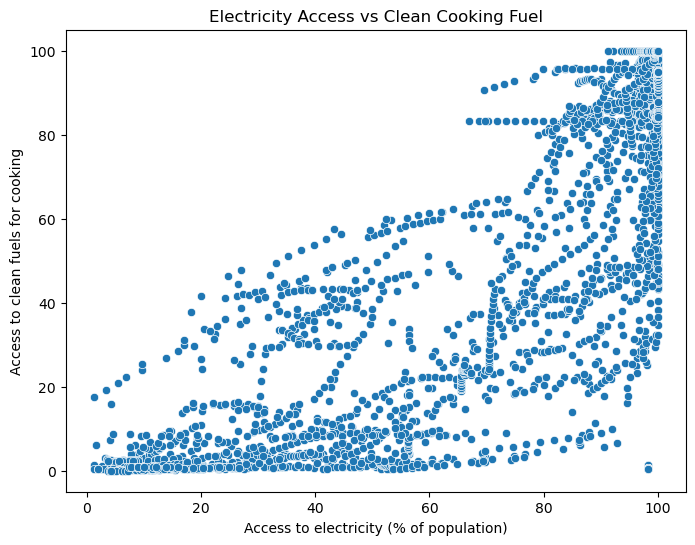

In [46]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Access to electricity (% of population)",
    y="Access to clean fuels for cooking",
    data=df
)

plt.title("Electricity Access vs Clean Cooking Fuel")
plt.show()

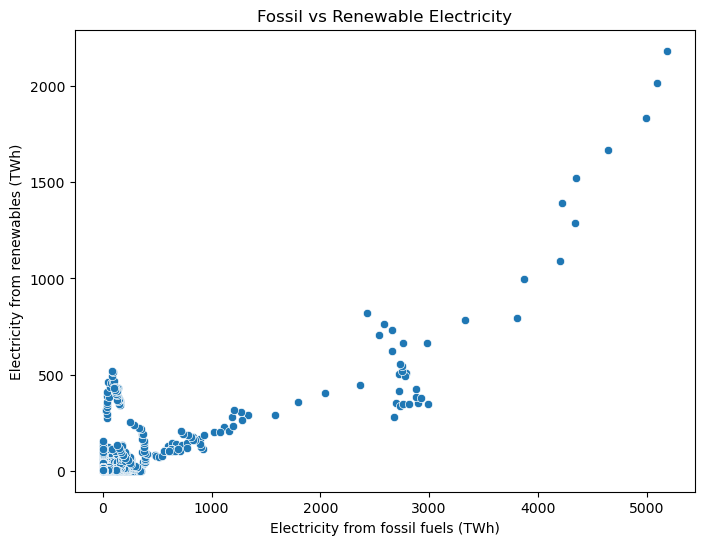

In [47]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Electricity from fossil fuels (TWh)",
    y="Electricity from renewables (TWh)",
    data=df
)

plt.title("Fossil vs Renewable Electricity")
plt.show()

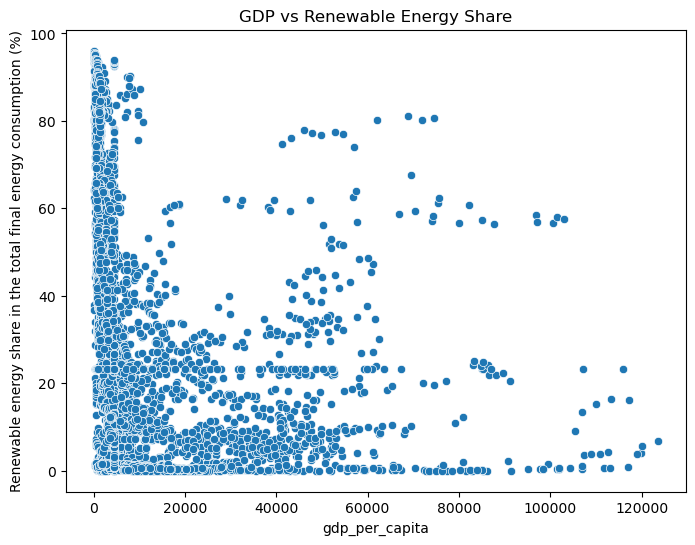

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="gdp_per_capita",
    y="Renewable energy share in the total final energy consumption (%)",
    data=df
)

plt.title("GDP vs Renewable Energy Share")
plt.show()

In [49]:
le = LabelEncoder()

df["Entity"] = le.fit_transform(df["Entity"])

In [50]:
scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [51]:
df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude,Total Electricity Production,Renewable Ratio
0,-1.715446,-1.658303,-2.558056,-1.511702,-0.390724,-0.217800,0.440606,-0.201180,-0.180943,-0.225954,...,-0.194394,-0.234874,0.019872,-0.421154,60,0.012086,0.649744,0.797318,-0.218425,1.010837
1,-1.715446,-1.493106,-2.476693,-1.485628,-0.392410,-0.217249,0.461525,-0.201382,-0.180943,-0.224129,...,-0.194436,-0.234874,0.019872,-0.421154,60,0.012086,0.649744,0.797318,-0.218178,1.576899
2,-1.715446,-1.327910,-2.300326,-1.459554,-0.394236,-0.198125,0.195069,-0.201266,-0.180943,-0.223553,...,-0.194024,-0.234874,0.019872,-0.651813,60,0.012086,0.649744,0.797318,-0.217973,1.468848
3,-1.715446,-1.162713,-2.124131,-1.425657,-0.396015,-0.087887,0.154946,-0.200748,-0.180943,-0.222881,...,-0.193763,-0.234874,0.990248,-0.651223,60,0.012086,0.649744,0.797318,-0.217459,1.042889
4,-1.715446,-0.997517,-1.948032,-1.389153,-0.397607,-0.189540,0.414886,-0.200690,-0.180943,-0.223553,...,-0.194024,-0.234874,-0.375045,-0.650138,60,0.012086,0.649744,0.797318,-0.217562,0.919365
